# 01. Exploratory Data Analysis

In [19]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.insert(0, str(Path("..").resolve() / "src"))
import data_prep as dp
import features as feat

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RAW_DIR = Path("../data/raw")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)

In [20]:
train = dp.load_data(RAW_DIR / "train.csv")

print(f"train: {train.shape[0]:,} rows x {train.shape[1]} columns")

train: 137 rows x 43 columns


## 1. Basic structure

Shape, dtypes.

In [21]:
train.head()

,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
0,0,1999-07-17,İstanbul,Big Cities,IL,4,5.0,4.0,4.0,2,2,5,4,5,5,3,5,5.0,1,2,2,2,4,5,4,1,3,3,1,1,1.0,4.0,2.0,3.0,5,3,4,5,5,4,3,4,5653753.0
1,1,2008-02-14,Ankara,Big Cities,FC,4,5.0,4.0,4.0,1,2,5,5,5,5,1,5,5.0,0,0,0,0,0,3,2,1,3,2,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,6923131.0
2,2,2013-03-09,Diyarbakır,Other,IL,2,4.0,2.0,5.0,2,3,5,5,5,5,2,5,5.0,0,0,0,0,0,1,1,1,1,1,0,0,0.0,0.0,1.0,3.0,0,0,0,0,0,0,0,0,2055379.0
3,3,2012-02-02,Tokat,Other,IL,6,4.5,6.0,6.0,4,4,10,8,10,10,8,10,7.5,6,4,9,3,12,20,12,6,1,10,2,2,2.5,2.5,2.5,7.5,25,12,10,6,18,12,12,6,2675511.0
4,4,2009-05-09,Gaziantep,Other,IL,3,4.0,3.0,4.0,2,2,5,5,5,5,2,5,5.0,2,1,2,1,4,2,2,1,2,1,2,3,3.0,5.0,1.0,3.0,5,1,3,2,3,4,3,3,4316715.0


In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 43 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Id          137 non-null    int64         
 1   Open Date   137 non-null    datetime64[ns]
 2   City        137 non-null    object        
 3   City Group  137 non-null    object        
 4   Type        137 non-null    object        
 5   P1          137 non-null    int64         
 6   P2          137 non-null    float64       
 7   P3          137 non-null    float64       
 8   P4          137 non-null    float64       
 9   P5          137 non-null    int64         
 10  P6          137 non-null    int64         
 11  P7          137 non-null    int64         
 12  P8          137 non-null    int64         
 13  P9          137 non-null    int64         
 14  P10         137 non-null    int64         
 15  P11         137 non-null    int64         
 16  P12         137 non-null  

In [23]:
missing = dp.missing_value_summary(train)
if missing.empty:
    print("No missing values in train.")
missing

No missing values in train.


,n_missing,pct_missing


In [24]:
dp.duplicate_summary(train)

{'full_row_duplicates': 0, 'content_duplicates_ignoring_id': 0}

## 2. Target variable: `revenue`



In [25]:
train["revenue"].describe()

count    1.370000e+02
mean     4.453533e+06
std      2.576072e+06
min      1.149870e+06
25%      2.999068e+06
50%      3.939804e+06
75%      5.166635e+06
max      1.969694e+07
Name: revenue, dtype: float64

In [26]:
raw_skew = train["revenue"].skew()
log_skew = np.log1p(train["revenue"]).skew()
print(f"Skew (raw revenue):        {raw_skew:.3f}")
print(f"Skew (log1p revenue):      {log_skew:.3f}")

q1, q3 = train["revenue"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = train[train["revenue"] > upper_fence]
print(f"\nIQR outlier fence: {upper_fence:,.0f}  ->  {len(outliers)} rows above it")
outliers.sort_values("revenue", ascending=False)

Skew (raw revenue):        2.793
Skew (log1p revenue):      0.307

IQR outlier fence: 8,417,986  ->  8 rows above it


,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
16,16,2000-01-07,İstanbul,Big Cities,FC,3,5.0,4.0,4.0,2,5,5,4,5,4,3,5,4.0,0,0,0,0,0,1,4,1,1,1,0,0,0.0,0.0,2.0,2.0,0,0,0,0,0,0,0,0,19696939.0
75,75,2005-10-15,İstanbul,Big Cities,FC,5,5.0,4.0,5.0,1,4,5,3,4,4,5,3,4.0,0,0,0,0,0,5,5,5,5,4,0,0,0.0,0.0,5.0,0.0,0,0,0,0,0,0,0,0,16549064.0
99,99,1999-12-18,İstanbul,Big Cities,IL,4,5.0,4.0,4.0,2,4,5,4,4,4,5,3,4.0,5,5,5,5,5,5,5,5,3,1,5,5,5.0,1.0,5.0,1.0,5,5,4,2,5,5,5,3,13575224.0
100,100,2007-09-21,İstanbul,Big Cities,FC,3,5.0,4.0,4.0,2,5,5,5,5,5,2,5,5.0,0,0,0,0,0,4,5,2,2,1,0,0,0.0,0.0,4.0,3.0,0,0,0,0,0,0,0,0,9652350.0
133,133,2006-10-12,İzmir,Big Cities,FC,4,5.0,4.0,4.0,2,3,5,4,4,5,5,4,5.0,0,0,0,0,0,3,2,2,1,1,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,9262754.0
24,24,2009-09-20,İstanbul,Big Cities,IL,5,5.0,3.0,5.0,2,2,5,5,5,4,2,5,4.0,4,4,4,5,4,5,5,2,2,3,2,2,2.0,5.0,3.0,2.0,5,5,4,4,4,4,5,2,8904084.0
116,116,2012-03-30,İzmir,Big Cities,FC,2,4.0,4.0,4.0,2,2,5,4,4,5,3,4,5.0,0,0,0,0,0,2,2,1,1,1,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,8894598.0
49,49,2008-04-01,İstanbul,Big Cities,FC,12,7.5,6.0,6.0,2,8,10,10,10,10,4,10,7.5,0,0,0,0,0,15,3,3,3,5,0,0,0.0,0.0,7.5,7.5,0,0,0,0,0,0,0,0,8630682.0


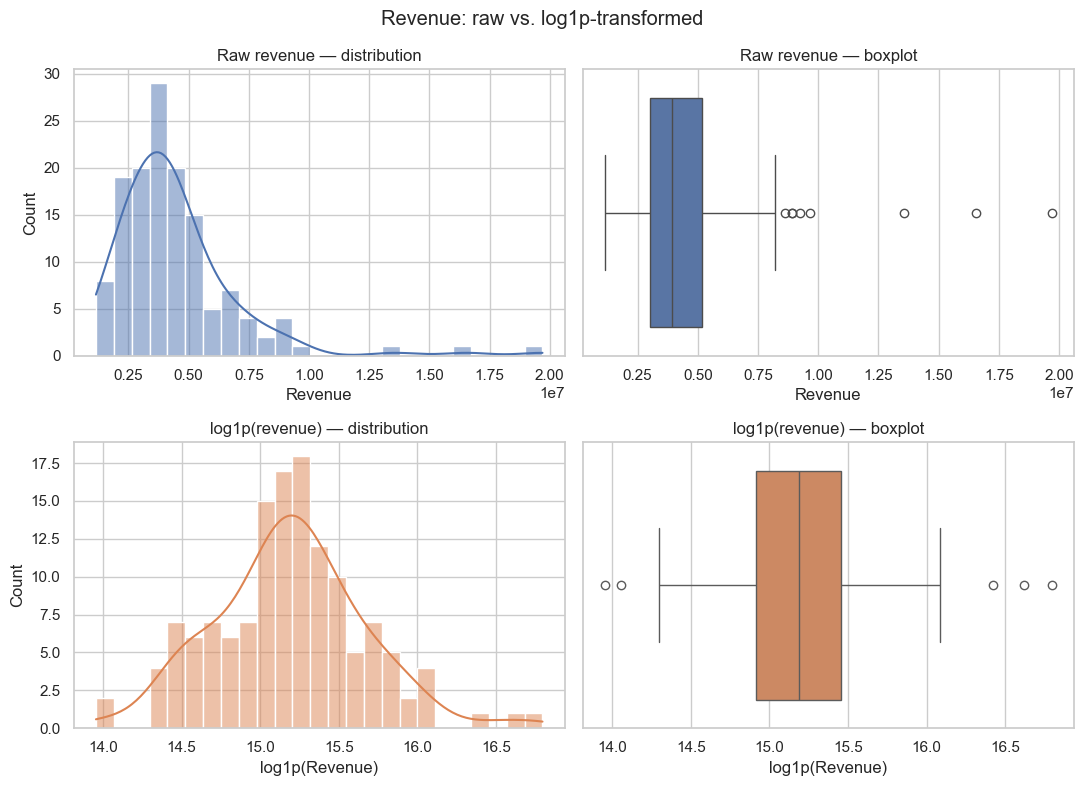

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(train["revenue"], bins=25, kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Raw revenue — distribution")
axes[0, 0].set_xlabel("Revenue")

sns.boxplot(x=train["revenue"], ax=axes[0, 1], color="#4C72B0")
axes[0, 1].set_title("Raw revenue — boxplot")
axes[0, 1].set_xlabel("Revenue")

log_revenue = np.log1p(train["revenue"])

sns.histplot(log_revenue, bins=25, kde=True, ax=axes[1, 0], color="#DD8452")
axes[1, 0].set_title("log1p(revenue) — distribution")
axes[1, 0].set_xlabel("log1p(Revenue)")

sns.boxplot(x=log_revenue, ax=axes[1, 1], color="#DD8452")
axes[1, 1].set_title("log1p(revenue) — boxplot")
axes[1, 1].set_xlabel("log1p(Revenue)")

fig.suptitle("Revenue: raw vs. log1p-transformed")
fig.tight_layout()
dp.save_fig(fig, "revenue_distribution.png", FIGURES_DIR)
plt.show()

Raw `revenue` is strongly right-skewed (skew ≈ 2.79). 8 restaurants sit above the IQR fence, all of them are from "Big Cities" locations, in particular: Istanbul and Izmir. 
`log1p(revenue)` brings skew down to 0.31, (close to symmetric).

## 3. Categorical variables: `City`, `City Group`, `Type`

In [28]:
for col in dp.CAT_COLUMNS:
    print(f"--- {col} ---")
    print(train[col].value_counts())
    print(f"n unique: {train[col].nunique()}\n")

--- City ---
City
İstanbul          50
Ankara            19
İzmir              9
Bursa              5
Samsun             5
Sakarya            4
Antalya            4
Kayseri            3
Eskişehir          3
Adana              3
Diyarbakır         3
Tekirdağ           3
Muğla              2
Trabzon            2
Aydın              2
Konya              2
Karabük            1
Isparta            1
Bolu               1
Kütahya            1
Amasya             1
Balıkesir          1
Denizli            1
Kocaeli            1
Kırklareli         1
Edirne             1
Uşak               1
Kastamonu          1
Tokat              1
Şanlıurfa          1
Elazığ             1
Gaziantep          1
Afyonkarahisar     1
Osmaniye           1
Name: count, dtype: int64
n unique: 34

--- City Group ---
City Group
Big Cities    78
Other         59
Name: count, dtype: int64
n unique: 2

--- Type ---
Type
FC    76
IL    60
DT     1
Name: count, dtype: int64
n unique: 3



- `City Group` balanced 2-level variable.
- `Type` heavily imbalanced: `FC` (76), `IL` (60),  `DT` (1) , `MB` (0).
- `City` high-cardinality (34 unique values across 137 rows), several of them singletons.

### City map: where are the restaurants?

The raw data has no per-restaurant coordinates, only a city name, so each city is placed at its
province-capital center (`dp.CITY_COORDS`) as a stand-in for restaurant location. Circle size is
the number of restaurants in that city; color is mean revenue.

In [29]:
import plotly.express as px

city_stats = dp.city_summary(train, target="revenue")

fig_map = px.scatter_geo(
    city_stats,
    lat="lat",
    lon="lon",
    size="n_restaurants",
    color="mean_target",
    hover_name="City",
    hover_data={"n_restaurants": True, "mean_target": ":.0f", "lat": False, "lon": False},
    color_continuous_scale="YlOrRd",
    size_max=40,
    scope="asia",
    title="Restaurants by city (size = count, color = mean revenue)",
)
fig_map.update_geos(
    lataxis_range=[35, 43], lonaxis_range=[25, 45], showcountries=True, showcoastlines=True
)
fig_map.update_layout(coloraxis_colorbar_title="Mean revenue")
fig_map.write_image(FIGURES_DIR / "city_map.png", width=900, height=600, scale=2)
fig_map.show()

## 4. `Open Date`: restaurant age

`Open Date` isn't useful as a raw timestamp, but the *age* of a restaurant at a fixed reference point is a natural, interpretable feature — older restaurants have had more time
to build a customer base. We use the TFI competition's launch date (2015-01-01) as the reference, (to be reproducable)

In [30]:
train["age_days"] = feat.compute_age_days(train)

print("Open Date range:", train["Open Date"].min().date(), "to", train["Open Date"].max().date())
train["age_days"].describe()

Open Date range: 1996-05-08 to 2014-01-25


count     137.000000
mean     2111.262774
std      1471.257507
min       341.000000
25%      1107.000000
50%      1773.000000
75%      2588.000000
max      6812.000000
Name: age_days, dtype: float64

Spearman corr(age_days, revenue) = 0.325  (p = 0.0001)


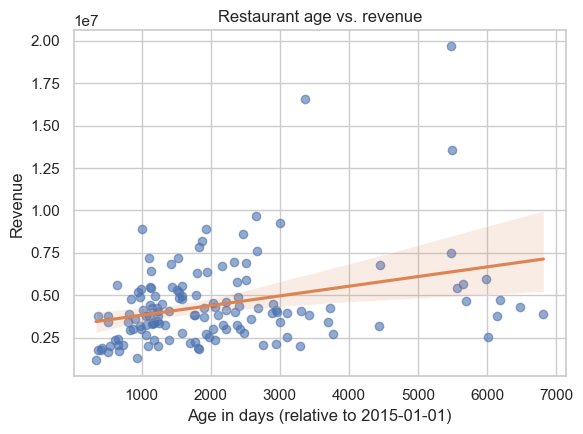

In [31]:
age_corr = stats.spearmanr(train["age_days"], train["revenue"])
print(f"Spearman corr(age_days, revenue) = {age_corr.correlation:.3f}  (p = {age_corr.pvalue:.4f})")

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.regplot(
    x=train["age_days"], y=train["revenue"], ax=ax,
    scatter_kws={"alpha": 0.6, "color": "#4C72B0"}, line_kws={"color": "#DD8452"},
)
ax.set_title("Restaurant age vs. revenue")
ax.set_xlabel("Age in days (relative to 2015-01-01)")
ax.set_ylabel("Revenue")
fig.tight_layout()
dp.save_fig(fig, "age_vs_revenue.png", FIGURES_DIR)
plt.show()

Age has a positive Spearman correlation with revenue (ρ ≈ 0.32, p < 0.001), older restaurants tend to earn more. It's a moderate relationship, so `age_days` is worth keeping as a feature.

## 5. `P1`-`P37`: obfuscated features

These 37 columns are anonymized (demographic, real estate, and commercial
indicators around each location). 

In [32]:
train[dp.P_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
P1,137.0,4.014599,2.910391,1.0,2.0,3.0,4.0,12.0
P2,137.0,4.408759,1.514900,1.0,4.0,5.0,5.0,7.5
P3,137.0,4.317518,1.032337,0.0,4.0,4.0,5.0,7.5
P4,137.0,4.372263,1.016462,3.0,4.0,4.0,5.0,7.5
P5,137.0,2.007299,1.209620,1.0,1.0,2.0,2.0,8.0
P6,137.0,3.357664,2.134235,1.0,2.0,3.0,4.0,10.0
P7,137.0,5.423358,2.296809,1.0,5.0,5.0,5.0,10.0
P8,137.0,5.153285,1.858567,1.0,4.0,5.0,5.0,10.0
P9,137.0,5.445255,1.834793,4.0,4.0,5.0,5.0,10.0
P10,137.0,5.489051,1.847561,4.0,5.0,5.0,5.0,10.0


In [33]:
near_constant = dp.flag_near_constant_columns(train, dp.P_COLUMNS, threshold=0.90)
sparse = dp.flag_sparse_columns(train, dp.P_COLUMNS, zero_threshold=0.5)

print(f"Near-constant columns (>=90% single value): {near_constant or 'none'}")
print(f"\nSparse columns (>=50% zeros): {len(sparse)} of {len(dp.P_COLUMNS)}")
print(sparse)

Near-constant columns (>=90% single value): none

Sparse columns (>=50% zeros): 17 of 37
['P14', 'P15', 'P16', 'P17', 'P18', 'P24', 'P25', 'P26', 'P27', 'P30', 'P31', 'P32', 'P33', 'P34', 'P35', 'P36', 'P37']


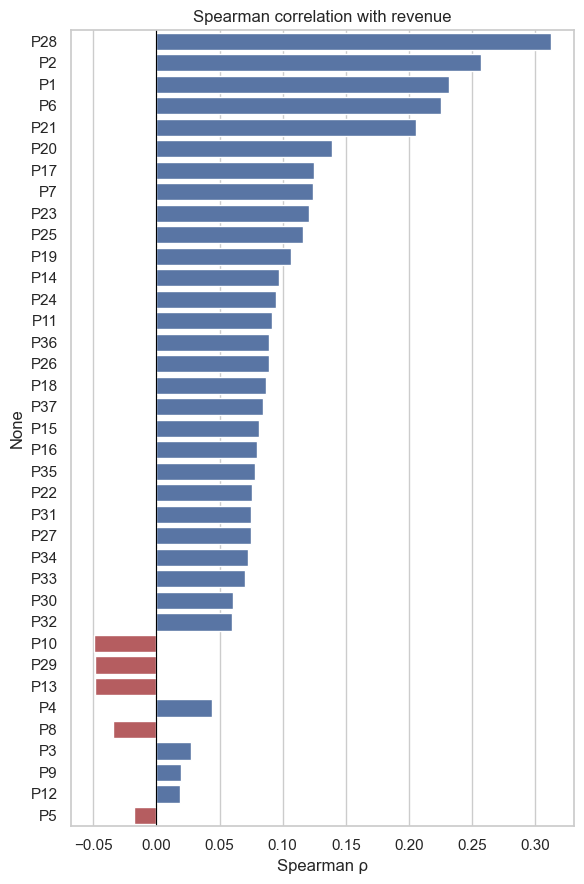

P28    0.312546
P2     0.256816
P1     0.231995
P6     0.225137
P21    0.205224
P20    0.139311
P17    0.124630
P7     0.123679
P23    0.120974
P25    0.115898
dtype: float64

In [34]:
p_corr = dp.spearman_correlation_with_target(train, dp.P_COLUMNS)

fig, ax = plt.subplots(figsize=(6, 9))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in p_corr.values]
sns.barplot(x=p_corr.values, y=p_corr.index, ax=ax, palette=colors, hue=p_corr.index, legend=False)
ax.set_title("Spearman correlation with revenue")
ax.set_xlabel("Spearman ρ")
ax.axvline(0, color="black", linewidth=0.8)
fig.tight_layout()
dp.save_fig(fig, "p_variables_correlation_with_revenue.png", FIGURES_DIR)
plt.show()

p_corr.head(10)

- No `P` column is near-constant at a 90% threshold, so none can be dropped outright for lack of variance. 
- **17 of the 37** columns (`P14`-`P18`, `P24`-`P27`,`P30`-`P37`) are ≥50% zeros, they are sparse categorical/ordinal indicators rather than smooth continuous measures, which matters for how they should be scaled/encoded. 
- On raw correlation, the strongest single predictors are `P28`,
`P2`, `P1`, `P6`, `P21` — but all are weak in isolation (|ρ| ≤ 0.33). 

**Takeaway: no single P variable explains revenue; the signal is spread thin across many weak features**

## 6. Correlation among `P` variables (multicollinearity check)

With 37 features and only 137 rows, redundant features add noise and instability (especially for
linear models) without adding information. A correlation heatmap surfaces clusters of P-variables
that move together.

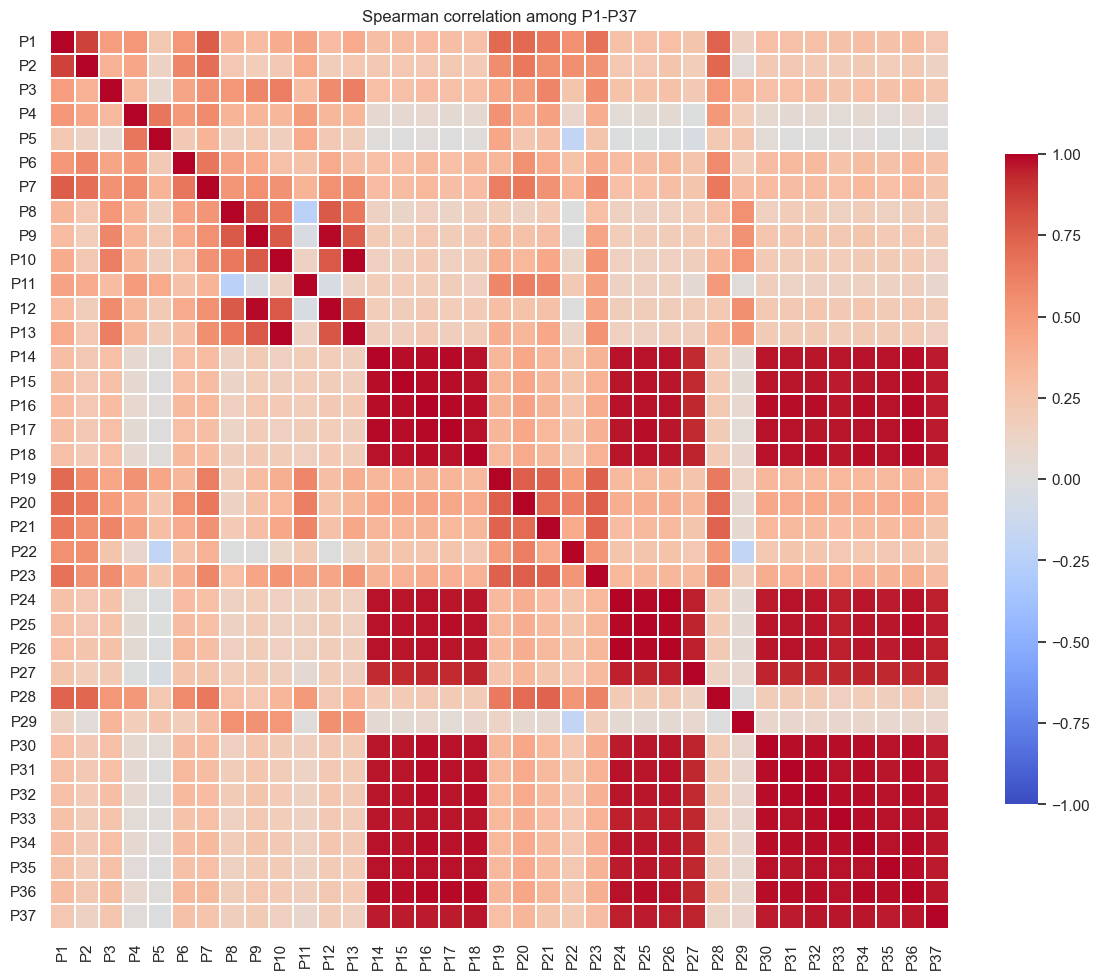

In [35]:
p_corr_matrix = train[dp.P_COLUMNS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    p_corr_matrix, ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.2, cbar_kws={"shrink": 0.7},
)
ax.set_title("Spearman correlation among P1-P37")
fig.tight_layout()
dp.save_fig(fig, "p_variables_correlation_heatmap.png", FIGURES_DIR)
plt.show()

In [36]:
corr_pairs = (
    p_corr_matrix.where(np.triu(np.ones(p_corr_matrix.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
)
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
corr_pairs.sort_values("abs_corr", ascending=False).head(10).drop(columns="abs_corr")

,level_0,level_1,corr
290,P10,P13,0.998385
576,P24,P26,0.993266
262,P9,P12,0.991194
454,P16,P36,0.990669
645,P31,P32,0.989855
588,P25,P26,0.988794
474,P17,P36,0.987985
493,P18,P36,0.987106
575,P24,P25,0.987042
661,P34,P36,0.985404


**What this shows:** the heatmap reveals visible blocks of correlated `P` variables rather than
37 independent signals — several pairs exceed |ρ| = 0.6. That's expected given they likely
encode overlapping real-estate/demographic facts about the same location.

## Summary

1. **Target is skewed — model on `log1p(revenue)`.** Raw revenue skew ≈ 2.79 drops to ≈ 0.31
   after `log1p`. The 8 IQR outliers are high-revenue (mostly İstanbul) restaurants, not
   data errors, and should be kept.
2. **`City` is high-cardinality, `Type` is imbalanced.** 34 unique cities and a single `DT`
   example across only 137 rows — both need care in encoding (prefer `City Group` over raw
   `City`) and in cross-validation (stratify or bucket `Type`) so no fold ends up with a category
   it never saw during training.
3. **Train is small (137 rows) relative to its feature space (37 `P` columns + categoricals).**
   Combined with correlated `P` blocks (Section 6), this points toward regularization,
   dimensionality reduction (PCA), or feature selection rather than using all 37 raw columns.
4. **No single `P` variable dominates.** The strongest (`P28`, `P2`, `P1`) are weak in isolation
   (|ρ| ≤ 0.33 with revenue), so the model needs to combine many weak, partly redundant signals —
   favors tree ensembles or regularized linear models over manual feature hand-picking.
5. **Restaurant age is a modest, usable signal** (ρ ≈ 0.32 with revenue, p < 0.001).

